In [1]:
# ============================== Block 1 ==============================
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

import flopy
import flopy.utils as fu

from matplotlib.path import Path as _MPPath
from matplotlib.patches import Patch

# -------------------------------
# Matplotlib defaults
# -------------------------------
plt.rcParams["figure.dpi"] = 120

# -------------------------------
# Paths
# -------------------------------
from pathlib import Path

root = Path.cwd()
workspace = root / "CS_A1" / "CrossSectionA_hetero"
workspace.mkdir(parents=True, exist_ok=True)

figs_path = workspace / "figures"
figs_path.mkdir(parents=True, exist_ok=True)

# -------------------------------
# Environment flags
# -------------------------------
def _get_env_bool(name: str, default: bool = True) -> bool:
    v = os.environ.get(name, str(default))
    return str(v).strip().lower() in {"1", "true", "t", "yes", "y", "on"}

write = _get_env_bool("WRITE", True)
run   = _get_env_bool("RUN", True)
plot  = _get_env_bool("PLOT", True)

# -------------------------------
# UNITS
# -------------------------------
length_units = "meters"
time_units   = "day"

# -------------------------------
# TIME (match realizations exactly)
# -------------------------------
TOTAL_YEARS    = 8000
INTERVAL_YEARS = 1000
nper   = TOTAL_YEARS // INTERVAL_YEARS              # 8
perlen = [365.0 * INTERVAL_YEARS] * nper            # days
nstp   = [2000] * nper                              # match realizations
tsmult = [1.0] * nper                               # match realizations

# -------------------------------
# GRID / MODEL (24 km × 300 m)
# -------------------------------
nlay = 30
nrow = 1
system_length = 24_000.0
ncol = 240                    # 100 m columns
delr = system_length / ncol
delc = 1.0
delv = 10.0
top  = 0.0
botm = [top - (k + 1) * delv for k in range(nlay)]  # -300 m

# -------------------------------
# SOLVER (robust for density coupling)
# -------------------------------
nouter, ninner = 800, 4000
hclose, rclose = 1e-4, 1e-2
relax          = 0.35

# -------------------------------
# Density / transport scalars
# -------------------------------
C0       = 0.0     # g/L (fresh)
Cmax     = 250.0   # g/L (brine)
buy_beta = 0.8     # kg/m^3 per g/L

# Dispersion / diffusion / porosity
alh = 30.0
ath1 = 5.0
atv = 0.20
diffusion_coefficient = 5.0e-9 * 86400.0  # m2/d
porosity_const = 0.30

# Hydraulic anisotropy
anisotropy_v = 5.0  # Kv = Kh/anisotropy_v

# Storage
Ss = 1e-4
Sy = 0.02

# -------------------------------
# Boundary & scaling
# -------------------------------
# Halite / brine nucleus lateral extent along A–A''' (used for CNC & IC)
HALITE_X_MAX_M        = 9000.0       # m  (≈ 0–9 km)
section_width_m       = 1.0
inflow_top_thickness_m = 100.0
head_salar            = -1.0


# -------------------------------
# Scenario inflow (driver looks here)
# -------------------------------
parameters = {"Scenario_A": {"inflow": 0.5}}  # m³/d total inflow (steady vertical stripe, fresh recharge)

# -------------------------------
# Facies colors/order (for plotting only)
# -------------------------------
FACIES_COLORS = {
    "sediments_bg": "#9fd3e6",
    "bedrock": "#c49a6c",
    "ignimbrite": "#f78da7",
    "ash": "#ffb347",
    "halite": "#4da3ff",
    "gypsum": "#ffd166",
    "alluvium_clay": "#a3a3a3",
    "carbonate": "#2ca25f",
    "silt": "#bdb76b",
}
FACIES_ORDER = ["bedrock","halite","gypsum","carbonate","ignimbrite","ash","alluvium_clay","silt","sediments_bg"]

# -------------------------------
# Hydraulic catalog
# -------------------------------
K_catalog = {
    "bedrock":        1e-7,
    "halite":         2.0,
    "gypsum":         5.0,
    "carbonate":      10.0,
    "ignimbrite":     0.5,
    "alluvium_clay":  1.0,
    "ash":            0.2,
}

# -------------------------------
# Geometry helpers & painters
# -------------------------------
def _close_poly(coords):
    if coords[0] != coords[-1]:
        return coords + [coords[0]]
    return coords

def rect(x0, x1, z0, z1):
    return _close_poly([(x0, z0), (x1, z0), (x1, z1), (x0, z1)])

def paint_bedrock_polyline(K3d, cat3d, *, top, delv, delr, nlay, ncol, k_bedrock, x_m, z_bedrock_m, fill="below"):
    x_m = np.asarray(x_m, float)
    z_bedrock_m = np.asarray(z_bedrock_m, float)
    x_centers = np.cumsum(np.full(ncol, delr)) - 0.5 * delr
    z_line = np.interp(x_centers, x_m, z_bedrock_m, left=z_bedrock_m[0], right=z_bedrock_m[-1])
    for i, z_i in enumerate(z_line):
        for k in range(nlay):
            zc = top - (k + 0.5) * delv
            is_bed = (zc <= z_i + 1e-9) if (fill == "below") else (zc >= z_i - 1e-9)
            if is_bed:
                K3d[k, 0, i] = k_bedrock
                cat3d[k, 0, i] = "bedrock"
    return K3d, cat3d

def paint_polygons_cat(K3d, cat3d, *, delr, delv, nlay, ncol, top, shapes):
    if not shapes:
        return K3d, cat3d
    x_centers = np.cumsum(np.full(ncol, delr)) - 0.5 * delr
    z_centers = top - (np.arange(nlay) + 0.5) * delv
    Xc, Zc = np.meshgrid(x_centers, z_centers)
    pts = np.c_[Xc.ravel(order="C"), Zc.ravel(order="C")]
    for shp in shapes:
        poly = np.asarray(_close_poly(shp["coords"]), float)
        inside = _MPPath(poly).contains_points(pts).reshape((nlay, ncol))
        inside3d = inside[:, None, :]
        K3d[inside3d]  = float(shp["Kh"])
        cat3d[inside3d] = shp["name"]
    return K3d, cat3d

def _band_along_poly(xp, zp, z_lo_off, z_hi_off, x_min=None, x_max=None):
    xp = np.asarray(xp, float); zp = np.asarray(zp, float)
    if x_min is None: x_min = float(np.min(xp))
    if x_max is None: x_max = float(np.max(xp))
    m = (xp >= x_min) & (xp <= x_max)
    xs = xp[m]; zl = zp[m] + float(z_lo_off); zu = np.minimum(zp[m] + float(z_hi_off), top)
    return _close_poly(list(zip(xs, zu)) + list(zip(xs[::-1], zl[::-1])))

def _band_over_vilama_bottom_curve(xp, zp, lo_x, lo_off, thickness, x_min, x_max):
    xp = np.asarray(xp, float); zp = np.asarray(zp, float)
    m = (xp >= x_min) & (xp <= x_max)
    xs = xp[m]
    lo = np.interp(xs, np.asarray(lo_x, float), np.asarray(lo_off, float))
    zlo = zp[m] + lo
    zhi = np.minimum(zlo + float(thickness), top)
    return _close_poly(list(zip(xs, zhi)) + list(zip(xs[::-1], zlo[::-1])))

def _top_of_ignimbrite_profile(xp, zp, ign_lo_x, ign_lo_off):
    def _f(x):
        x = np.asarray(x, float)
        zbed = np.interp(x, xp, zp)
        ign_btm_off = np.interp(x, ign_lo_x, ign_lo_off)
        return zbed + ign_btm_off + 30.0
    return _f

def _clip_right_by_barrier(xL, xR, z_bottom, z_top_ign, pad=1.0):
    xs = np.linspace(xL, xR, 400); zbar = z_top_ign(xs)
    ok = z_bottom >= zbar
    if not np.any(ok): return xL
    xR_clip = xs[np.where(ok)[0].max()]
    return max(xL, min(xR, xR_clip - pad))

# -------------------------------
# Guard: ensure everything above ran before building geometry
# -------------------------------
_required = [
    'np','top','delv','nlay','ncol','botm','system_length','K_catalog',
    'rect','_clip_right_by_barrier','_band_along_poly','_band_over_vilama_bottom_curve',
    '_top_of_ignimbrite_profile'
]
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise RuntimeError(f"Block 1 did not initialize completely. Missing: {_missing}")

# -------------------------------
# Scenario A geometry (built from the globals above)
# -------------------------------
botm_geom = botm
system_length_geom = float(system_length)
BEDROCK_START_M = 7_000.0
BEDROCK_END_M   = system_length_geom
BEDROCK_KILL_Z  = botm_geom[-1] - 500.0

x_m_A = [0.0, BEDROCK_START_M - 1.0, BEDROCK_START_M, 11_000.0, 14_000.0, 17_000.0, 20_000.0, BEDROCK_END_M]
zbed_A = [BEDROCK_KILL_Z, BEDROCK_KILL_Z, botm_geom[-1], -210.0, -150.0, -115.0, -95.0, -85.0]

carb_band_A = {"name":"carbonate","Kh":K_catalog["carbonate"],
               "coords": _band_along_poly(x_m_A, zbed_A, 0.0, 30.0, BEDROCK_START_M, BEDROCK_END_M)}

IGN_BLEND_LEN = 1000.0
ign_lo_x = [BEDROCK_START_M, BEDROCK_START_M + IGN_BLEND_LEN, BEDROCK_END_M]
ign_lo_off = [0.0, 30.0, 30.0]
ign_band_A = {"name":"ignimbrite","Kh":K_catalog["ignimbrite"],
              "coords": _band_over_vilama_bottom_curve(x_m_A, zbed_A, ign_lo_x, ign_lo_off, 30.0,
                                                       BEDROCK_START_M, BEDROCK_END_M)}
z_top_ign = _top_of_ignimbrite_profile(np.asarray(x_m_A,float), np.asarray(zbed_A,float),
                                       np.asarray(ign_lo_x,float), np.asarray(ign_lo_off,float))

gypsum_left = {"name":"gypsum","Kh":K_catalog["gypsum"],
               "coords": rect(0.0, BEDROCK_START_M, botm_geom[-1], -200.0)}

# Mid and upper stripes + halite peeks
xL_base, xR_base = 9_000.0, 21_000.0
z_lo_mid, z_hi_mid = -180.0, -40.0
thick_mid = 8.0

mid_stripes = []
z = z_lo_mid; i = 0
while z < z_hi_mid - 1e-6:
    is_carb = (i % 2 == 0)
    shift = 300.0 * (z - z_lo_mid) / (z_hi_mid - z_lo_mid)
    xL = xL_base + shift
    rt = max(0.0, 200.0 * (z - (z_hi_mid - 30.0)) / 30.0)
    xR_candidate = xR_base - rt
    xR = _clip_right_by_barrier(xL, xR_candidate, z_bottom=z, z_top_ign=z_top_ign)
    if xR > xL + 0.5:
        mid_stripes.append({"name":"carbonate" if is_carb else "gypsum",
                            "Kh": K_catalog["carbonate"] if is_carb else K_catalog["gypsum"],
                            "coords": rect(xL, xR, z, min(z + thick_mid, z_hi_mid))})
    z += thick_mid; i += 1

def _add_window_stripes(z_lo, z_hi, dz, left_shift, right_taper, first="gypsum"):
    out=[]; z=z_lo; n=0
    while z < z_hi - 1e-6:
        name = first if (n%2==0) else ("carbonate" if first=="gypsum" else "gypsum")
        Kh = K_catalog[name]; frac = (z - z_lo)/max(1e-9, (z_hi - z_lo))
        xL = xL_base + left_shift*frac; xR_candidate = xR_base - right_taper*frac
        xR = _clip_right_by_barrier(xL, xR_candidate, z_bottom=z, z_top_ign=z_top_ign)
        if xR > xL + 0.5: out.append({"name":name,"Kh":Kh,"coords":rect(xL, xR, z, min(z+dz, z_hi))})
        z += dz; n += 1
    return out

upper_stripes  = _add_window_stripes(-40.0, -20.0, 6.0, 200.0, 350.0, "gypsum")
upper_stripes += _add_window_stripes(-20.0,  -8.0, 5.0, 250.0, 450.0, "carbonate")
upper_stripes += _add_window_stripes( -8.0,  -2.0, 4.0, 350.0, 550.0, "gypsum")

halite_peeks = []
for xL, xR_can, z0 in [(8700.0,14000.0,-155.0),(8900.0,15000.0,-140.0),(9100.0,15300.0,-128.0),
                       (9300.0,15700.0,-118.0),(9600.0,16000.0,-108.0)]:
    xR = _clip_right_by_barrier(xL, xR_can, z_bottom=z0, z_top_ign=z_top_ign)
    if xR > xL + 0.5:
        halite_peeks.append({"name":"halite","Kh":K_catalog["halite"],"coords":rect(xL, xR, z0, z0+4.0)})

alluvium_cap = {"name":"alluvium_clay","Kh":K_catalog["alluvium_clay"],"coords":rect(19400.0, BEDROCK_END_M, -35.0, 0.0)}
ash_lines_A  = [rect(1000.0, 6000.0, -210.0, -200.0), rect(20300.0, 21300.0, -115.0, -105.0)]
ash_objs_A   = [{"name":"ash","Kh":K_catalog["ash"],"coords":c} for c in ash_lines_A]

facies_A = [gypsum_left, carb_band_A, ign_band_A] + mid_stripes + upper_stripes + halite_peeks + ash_objs_A + [alluvium_cap]

# Register scenarios for downstream blocks
scenarios = {"Scenario_A": {"x": x_m_A, "z": zbed_A, "facies": facies_A}}


In [2]:
# ============================== Block 2 ==============================
assert nrow == 1, "This workflow assumes a 2D cross-section (nrow == 1)."
assert len(botm) == nlay, "botm length must equal nlay."
assert np.isclose(delr * ncol, system_length), "Check system_length, delr, ncol consistency."

def summarize_config():
    print("[CONFIG]")
    print(f" workspace: {workspace}")
    print(f" nlay×nrow×ncol: {nlay} × {nrow} × {ncol}")
    print(f" delr, delc, delv: {delr}, {delc}, {delv}")
    print(f" system_length: {system_length}")
    print(f" time: nper={nper}, perlen[0]={perlen[0]}, nstp[0]={nstp[0]}, units={time_units}")
    print(f" density: C0={C0} g/L, Cmax={Cmax} g/L, beta={buy_beta} kg/m^3 per g/L")
    print(f" anisotropy_v: {anisotropy_v}, Ss={Ss}, Sy={Sy}")
    print(f" head_salar: {head_salar} m")
    print(f" GHB extent (m): {GHB_X_MAX_M}, ")
    print(f" solver: nouter={nouter}, ninner={ninner}, relax={relax}")
    print(f" env flags: write={write}, run={run}, plot={plot}")


In [3]:
# ============================== Block 3 (build models: flow + transport, BCs, coupling) ==============================
import flopy
import numpy as np

def write_models(sim, silent=True):
    sim.write_simulation(silent=silent)


def build_models(sim_folder, inflow=None, geo=None):
    """
    Build a coupled GWF–GWT MF6 simulation with:
      - Left full-depth CHD (nucleus edge, head = head_salar)
      - Full-depth CNC brine from x = 0–GHB_X_MAX_M
      - Surface DRN evap zone from ~2–8 km along x (top layer only)
      - Right fresh WEL inflow stripe (upper inflow_top_thickness_m)
      - BUY density coupling using GWT concentration
    """
    sim_ws = workspace / sim_folder

    sim = flopy.mf6.MFSimulation(
        sim_name=sim_folder,
        exe_name="mf6.exe",
        sim_ws=sim_ws,
    )

    # ------------------------------------------------------------------
    # TDIS
    # ------------------------------------------------------------------
    perioddata = [(float(perlen[i]), int(nstp[i]), float(tsmult[i])) for i in range(int(nper))]
    flopy.mf6.ModflowTdis(
        sim,
        time_units="DAYS",
        nper=int(nper),
        perioddata=perioddata,
    )

    # ------------------------------------------------------------------
    # IMS (separate for flow and transport)
    # ------------------------------------------------------------------
    ims_flow = flopy.mf6.ModflowIms(
        sim,
        pname="IMS-FLOW",
        filename="flow.ims",
        print_option="SUMMARY",
        complexity="complex",
        outer_maximum=int(nouter),
        outer_dvclose=float(hclose),
        inner_maximum=int(ninner),
        inner_dvclose=float(hclose),
        rcloserecord=float(rclose),
        relaxation_factor=float(relax),
    )

    ims_trans = flopy.mf6.ModflowIms(
        sim,
        pname="IMS-TRANS",
        filename="trans.ims",
        print_option="SUMMARY",
        complexity="moderate",
        outer_maximum=int(nouter),
        outer_dvclose=float(hclose),
        inner_maximum=int(ninner),
        inner_dvclose=float(hclose),
        rcloserecord=float(rclose),
        relaxation_factor=float(relax),
    )

    # ------------------------------------------------------------------
    # GWF model (flow)
    # ------------------------------------------------------------------
    gwf = flopy.mf6.ModflowGwf(
        sim,
        modelname="flow",
        save_flows=True,
        newtonoptions="NEWTON",
    )
    sim.register_ims_package(ims_flow, [gwf.name])

    # DIS
    dis_gwf = flopy.mf6.ModflowGwfdis(
        gwf,
        nlay=int(nlay),
        nrow=int(nrow),
        ncol=int(ncol),
        length_units="METERS",
        xorigin=0.0,
        yorigin=0.0,
        delr=delr,
        delc=delc,
        top=top,
        botm=botm,
    )

    K_hal = float(K_catalog["halite"])

    # start with all halite
    K3d = np.full((nlay, 1, ncol), K_hal, dtype=float)
    cat3d = np.full((nlay, 1, ncol), "halite", dtype=object)

    # facies polygons from this scenario
    K3d, cat3d = paint_polygons_cat(
        K3d,
        cat3d,
        delr=delr,
        delv=delv,
        nlay=nlay,
        ncol=ncol,
        top=top,
        shapes=geo.get("facies", []),
    )

    # bedrock polyline from this scenario
    K3d, cat3d = paint_bedrock_polyline(
        K3d,
        cat3d,
        top=top,
        delv=delv,
        delr=delr,
        nlay=nlay,
        ncol=ncol,
        k_bedrock=K_catalog["bedrock"],
        x_m=geo["x"],
        z_bedrock_m=geo["z"],
        fill="below",
    )

    # --- NPF uses painted K3d ---
    k33 = (K3d / anisotropy_v).tolist()
    flopy.mf6.ModflowGwfnpf(
        gwf,
        save_specific_discharge=True,
        icelltype=0,
        k=K3d.tolist(),
        k33=k33,
    )
    # Storage (confined everywhere; iconvert = 0)
    steady = {0: False}
    transient = {kper: True for kper in range(int(nper))}
    flopy.mf6.ModflowGwfsto(
        gwf,
        iconvert=0,
        ss=float(Ss),
        sy=float(Sy),
        steady_state=steady,
        transient=transient,
        save_flows=True,
    )

    # Initial heads: uniform head_salar
    flopy.mf6.ModflowGwfic(
        gwf,
        strt=float(head_salar),
    )

    # ------------------------------------------------------------------
    # GWT model (transport)
    # ------------------------------------------------------------------
    gwt = flopy.mf6.ModflowGwt(
        sim,
        modelname="trans",
        save_flows=True,
    )
    sim.register_ims_package(ims_trans, [gwt.name])

    dis_gwt = flopy.mf6.ModflowGwtdis(
        gwt,
        nlay=int(nlay),
        nrow=int(nrow),
        ncol=int(ncol),
        delr=delr,
        delc=delc,
        top=top,
        botm=botm,
    )

    # ------------------------------------------------------------------
    # GWT INITIAL CONCENTRATION – brine in 0–9 km, 0–250 m,
    # excluding bedrock / ignimbrite / carbonate
    # ------------------------------------------------------------------
    C_ic = np.full((int(nlay), int(nrow), int(ncol)), float(C0), dtype=float)

    # geometric extents of the brine pool
    HALITE_X_MAX_M     = 9000.0   # 0–9 km laterally
    HALITE_THICKNESS_M = 250.0    # 0 to -250 m vertically

    # convert to indices
    j_cnc_max = min(int(HALITE_X_MAX_M / float(delr)), int(ncol) - 1)
    n_halite_layers = min(int(HALITE_THICKNESS_M / float(delv)), int(nlay))

    # start with a simple geometric mask: top N layers, first J columns
    brine_mask = np.zeros_like(cat3d, dtype=bool)   # (nlay, 1, ncol)
    brine_mask[0:n_halite_layers, 0, 0 : j_cnc_max + 1] = True

    # now exclude bedrock / ignimbrite / carbonate facies
    forbidden_facies = np.isin(cat3d, ["bedrock", "ignimbrite", "carbonate"])
    brine_mask &= ~forbidden_facies

    # apply IC: brine only where brine_mask is True
    C_ic[brine_mask] = float(Cmax)

    flopy.mf6.ModflowGwtic(
        gwt,
        strt=C_ic,
    )

    # Transport properties
    flopy.mf6.ModflowGwtmst(gwt, porosity=float(porosity_const))
    flopy.mf6.ModflowGwtadv(gwt, scheme="UPSTREAM")
    flopy.mf6.ModflowGwtdsp(
        gwt,
        alh=float(alh),
        ath1=float(ath1),
        atv=float(atv),
        diffc=float(diffusion_coefficient),
    )

    # ------------------------------------------------------------------
    # GWF BOUNDARIES
    # ------------------------------------------------------------------

    inflow_total = float(inflow if inflow is not None else parameters.get(sim_folder, {}).get("inflow", 0.5))

    # (A) LEFT CHD – full-depth fixed head at x = 0 m
    chd_cells = [((k, 0, 0), float(head_salar)) for k in range(int(nlay))]
    chd_spd = {sp: chd_cells for sp in range(int(nper))}
    flopy.mf6.ModflowGwfchd(
        gwf,
        stress_period_data=chd_spd,
        pname="CHD-NUCLEUS",
        save_flows=True,
    )

    # (B) DRN Evaporation Zone – TOP LAYER, x ≈ 9.5–15 km (upgradient side)
    top_arr = dis_gwf.top.array  # (nrow, ncol)

    j_evap_start = max(0, min(int(round(9500.0 / float(delr))), int(ncol) - 1))   # ~9.5 km
    j_evap_end   = max(0, min(int(round(15000.0 / float(delr))), int(ncol) - 1))  # ~15 km
    if j_evap_end < j_evap_start:
        j_evap_start, j_evap_end = j_evap_end, j_evap_start

    drn_cells_idx = []
    for j in range(j_evap_start, j_evap_end + 1):
        elev = float(top_arr[0, j])
        drn_cells_idx.append(((0, 0, j), elev))  # only top layer

    if drn_cells_idx:
        n_drn = len(drn_cells_idx)
        cond_per_cell = inflow_total / float(n_drn)

        drn_spd = {
            sp: [
                (cid, elev, cond_per_cell, float(C0))
                for (cid, elev) in drn_cells_idx
            ]
            for sp in range(int(nper))
        }

        flopy.mf6.ModflowGwfdrn(
            gwf,
            stress_period_data=drn_spd,
            pname="DRN-EVAP",
            auxiliary=["CONCENTRATION"],
            save_flows=True,
        )

    # (C) RIGHT Fresh Inflow WEL – upper 100 m (inflow_top_thickness_m)
    j_right = int(ncol) - 1
    bedrock_thresh = max(float(np.nanmax(K3d)) * 1e-6, 1e-9)

    candidate_layers = [k for k in range(int(nlay)) if K3d[k, 0, j_right] > bedrock_thresh]
    if not candidate_layers:
        candidate_layers = list(range(int(nlay)))

    inflow_cells = []
    cum_dz = 0.0
    for k in candidate_layers:
        if cum_dz + float(delv) <= float(inflow_top_thickness_m):
            inflow_cells.append((k, 0, j_right))
            cum_dz += float(delv)
        else:
            break

    q_per_cell = inflow_total / float(len(inflow_cells))

    wel_spd = {
        sp: [[cell, q_per_cell, float(C0)] for cell in inflow_cells]
        for sp in range(int(nper))
    }

    flopy.mf6.ModflowGwfwel(
        gwf,
        stress_period_data=wel_spd,
        pname="WEL-RIGHT",
        auxiliary=["CONCENTRATION"],
        save_flows=True,
    )

    # ------------------------------------------------------------------
    # GWT BOUNDARIES (CNC + SSM)
    # ------------------------------------------------------------------

    # CNC – pin concentration ONLY where the IC brine exists
    cnc_cells = []
    k_idx, _, j_idx = np.where(brine_mask)
    for k, j in zip(k_idx, j_idx):
        cnc_cells.append(((int(k), 0, int(j)), float(Cmax)))

    cnc_spd = {sp: cnc_cells for sp in range(int(nper))}

    flopy.mf6.ModflowGwtcnc(
        gwt,
        stress_period_data=cnc_spd,
        pname="CNC-HALITE",
        save_flows=True,
    )

    # SSM maps DRN + WEL concentrations into transport
    flopy.mf6.ModflowGwtssm(
        gwt,
        sources=[
            ("WEL-RIGHT", "AUX", "CONCENTRATION"),
            ("DRN-EVAP",  "AUX", "CONCENTRATION"),
        ],
        save_flows=True,
    )

    # ------------------------------------------------------------------
    # BUY density coupling & GWF–GWT exchange
    # ------------------------------------------------------------------
    flopy.mf6.ModflowGwfbuy(
        gwf,
        nrhospecies=1,
        denseref=1000.0,
        packagedata=[(0, float(buy_beta), 0.0, gwt.name, "CONCENTRATION")],
    )

    flopy.mf6.ModflowGwfgwt(
        sim,
        exgtype="GWF6-GWT6",
        exgmnamea=gwf.name,
        exgmnameb=gwt.name,
        filename="flow.gwfgwt",
    )


    # ------------------------------------------------------------------
    # OUTPUT CONTROL
    # ------------------------------------------------------------------
    flopy.mf6.ModflowGwfoc(
        gwf,
        head_filerecord="flow.hds",
        budget_filerecord="flow.bud",
        saverecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
        printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
    )

    flopy.mf6.ModflowGwtoc(
        gwt,
        concentration_filerecord="trans.ucn",
        budget_filerecord="trans.cbc",
        saverecord=[("CONCENTRATION", "LAST"), ("BUDGET", "LAST")],
        printrecord=[("CONCENTRATION", "LAST"), ("BUDGET", "LAST")],
    )

    gwf._facies_cat = cat3d

    return sim


In [4]:
# ============================== Block 4 ==============================
from pathlib import Path as _Path
import numpy as np
import matplotlib.pyplot as plt
import flopy.utils as fu
from matplotlib.patches import Patch

figure_size = (12, 5)

def _grid_coords(dis):
    delrA = dis.delr.array
    topA  = dis.top.array
    botmA = dis.botm.array
    nlayA = int(dis.nlay.data)
    x = np.cumsum(delrA) - 0.5 * delrA
    z_top = float(topA[0,0]); z_bot = float(botmA[-1,0,0])
    z = z_top - (np.arange(nlayA) + 0.5) * (z_top - z_bot) / nlayA
    return x, z, topA, botmA, delrA

def _read_last_array_safely(path, kind="head"):
    path = _Path(path)
    if not path.exists() or path.stat().st_size < 512:
        return None, None
    tries = []
    if kind=="head":
        tries=[(fu.HeadFile, {"precision":"double"}),(fu.HeadFile, {"precision":"single"})]
    elif kind=="ucn":
        tries=[(fu.UcnFile, {"precision":"double"}),(fu.UcnFile, {"precision":"single"}),
               (fu.HeadFile, {"text":"CONCENTRATION","precision":"double"}),
               (fu.HeadFile, {"text":"CONCENTRATION","precision":"single"})]
    last_err=None
    for cls, kw in tries:
        try:
            fh = cls(path.as_posix(), **kw)
            times = fh.get_times()
            if not times: continue
            arr = fh.get_data(totim=times[-1])
            return times, arr
        except Exception as e:
            last_err=e
    print(f"[read_safely] Failed {path.name}: {last_err}")
    return None, None

def _read_nearest_time_array(path, target_totim, kind="head"):
    """Return array at the file time closest to target_totim (days)."""
    path = _Path(path)
    if not path.exists() or path.stat().st_size < 512:
        return None, None
    tries = []
    if kind=="head":
        tries=[(fu.HeadFile, {"precision":"double"}),(fu.HeadFile, {"precision":"single"})]
    elif kind=="ucn":
        tries=[(fu.UcnFile, {"precision":"double"}),(fu.UcnFile, {"precision":"single"}),
               (fu.HeadFile, {"text":"CONCENTRATION","precision":"double"}),
               (fu.HeadFile, {"text":"CONCENTRATION","precision":"single"})]
    last_err=None
    for cls, kw in tries:
        try:
            fh = cls(path.as_posix(), **kw)
            times = fh.get_times()
            if not times: continue
            # choose nearest time
            diffs = [abs(float(t)-float(target_totim)) for t in times]
            idx = int(np.argmin(diffs))
            totim = float(times[idx])
            arr = fh.get_data(totim=totim)
            return totim, arr
        except Exception as e:
            last_err=e
    print(f"[read_nearest] Failed {path.name}: {last_err}")
    return None, None

# -------- baseline plots (last-time) --------
def plot_hydrostrat(sim, title="Hydrostrat — Scenario_A"):
    gwf = sim.get_model("flow"); dis = gwf.get_package("dis")
    x, _, topA, botmA, delrA = _grid_coords(dis)
    nlay_ = int(dis.nlay.data); ncol_ = int(dis.ncol.data)
    cat3d = getattr(gwf, "_facies_cat", None)
    if cat3d is None:
        K = gwf.npf.k.array[:,0,:]
        thresh = max(np.nanmax(K)*1e-6, 1e-9)
        cat2d = np.where(K <= thresh, "bedrock", "sediments_bg")
    else:
        cat2d = cat3d[:,0,:]

    layer_tops = np.vstack([topA, botmA[:-1,0,:]])
    layer_bots = botmA[:,0,:]
    fig, ax = plt.subplots(figsize=figure_size)
    for k in range(nlay_):
        ytop, ybot = layer_tops[k,:], layer_bots[k,:]
        for j in range(ncol_):
            name = str(cat2d[k,j])
            color = FACIES_COLORS.get(name, "#cccccc")
            ax.fill_between([x[j]-0.5*delrA[j], x[j]+0.5*delrA[j]],
                            [ybot[j], ybot[j]], [ytop[j], ytop[j]],
                            color=color, edgecolor="k", linewidth=0.15)
    ax.set_xlabel("Horizontal Distance (m)")
    ax.set_ylabel("Elevation (m)")
    ax.set_title(title)
    ax.set_ylim(float(botmA[-1,0,0]), float(topA[0,0]))
    present = sorted({str(v) for v in cat2d.ravel()},
                     key=lambda n: FACIES_ORDER.index(n) if n in FACIES_ORDER else 999)
    patches = [Patch(facecolor=FACIES_COLORS.get(n,"#ccc"), edgecolor="k", label=n) for n in present]
    ax.legend(handles=patches, loc="upper left", ncol=min(4, len(patches)))
    plt.tight_layout(); plt.show()

def plot_heads(sim, title="Head (last) + Bedrock — Scenario_A"):
    gwf = sim.get_model("flow"); dis = gwf.get_package("dis")
    x, z, *_ = _grid_coords(dis)
    _, H3d = _read_last_array_safely(_Path(gwf.model_ws)/"flow.hds", kind="head")
    if H3d is None: return
    H = H3d[:,0,:].astype(float)
    X, Z = np.meshgrid(x, z)
    fig, ax = plt.subplots(figsize=figure_size)
    cs = ax.contourf(X, Z, H, levels=40, cmap="viridis"); plt.colorbar(cs, ax=ax, label="Head (m)")
    # bedrock shading
    K = gwf.npf.k.array[:,0,:]; thresh = max(np.nanmax(K)*1e-6, 1e-9)
    bed = (K <= thresh).astype(float)
    ax.contourf(X, Z, bed, levels=[0.5,1.5], colors=["#c7b08b"], alpha=0.35)
    ax.set_xlabel("Horizontal Distance (m)"); ax.set_ylabel("Elevation (m)")
    ax.set_ylim(float(dis.botm.array[-1,0,0]), float(dis.top.array[0,0]))
    ax.set_title(title); plt.tight_layout(); plt.show()

def plot_salinity_at(sim, years, title_prefix="Salinity"):
    gwt = sim.get_model("trans")
    if gwt is None: return
    dis = gwt.get_package("dis")
    x, z, *_ = _grid_coords(dis)
    totim = float(years) * 365.0
    t_used, C3d = _read_nearest_time_array(_Path(gwt.model_ws)/"trans.ucn", totim, kind="ucn")
    if C3d is None:
        print(f"[salinity_at] no data near {years} yr"); return
    C = C3d[:,0,:]
    X, Z = np.meshgrid(x, z)
    fig, ax = plt.subplots(figsize=figure_size)
    levels = np.linspace(0.0, float(Cmax), 41)  # fixed scale 0..Cmax
    cs = ax.contourf(X, Z, C, levels=levels, cmap="viridis")
    plt.colorbar(cs, ax=ax, label="Concentration (g/L)")
    ax.set_xlabel("Horizontal Distance (m)"); ax.set_ylabel("Elevation (m)")
    ax.set_ylim(float(dis.botm.array[-1,0,0]), float(dis.top.array[0,0]))
    ax.set_title(f"{title_prefix} (t≈{t_used/365:.1f} yr)")
    plt.tight_layout(); plt.show()

def plot_quiver_at(sim, years, every=3, title_prefix="Head + Specific discharge"):
    gwf = sim.get_model("flow")
    if gwf is None: return
    dis = gwf.get_package("dis")
    x, z, *_ = _grid_coords(dis)
    totim = float(years) * 365.0

    # head at nearest time
    t_used, H3d = _read_nearest_time_array(_Path(gwf.model_ws)/"flow.hds", totim, kind="head")
    if H3d is None:
        print(f"[quiver_at] no head near {years} yr"); return
    H = H3d[:,0,:]

    # read SPDIS (or face flows) at the requested time
    qx=qz=None
    bud_path = _Path(gwf.model_ws)/"flow.bud"
    if bud_path.exists():
        try:
            cbb = fu.CellBudgetFile(bud_path.as_posix(), precision="double")
            sp = cbb.get_data(text="DATA-SPDIS", totim=t_used)
            if sp:
                rec = sp[0]
                qx = rec["qx"].reshape((int(dis.nlay.data),1,int(dis.ncol.data)))[:,0,:]
                qz = rec["qz"].reshape((int(dis.nlay.data),1,int(dis.ncol.data)))[:,0,:]
            else:
                qxr = cbb.get_data(text="FLOW RIGHT FACE", totim=t_used)[0][:,0,:]
                qzl = cbb.get_data(text="FLOW LOWER FACE", totim=t_used)[0][:,0,:]
                qx = 0.5*(qxr[:,:-1] + qxr[:,1:])
                qz = 0.5*(qzl[:-1,:] + qzl[1:,:])

            # optional global vmax pass for color scaling
            qmax_global = 0.0
            for tt in cbb.get_times():
                try:
                    sp_tt = cbb.get_data(text="DATA-SPDIS", totim=tt)
                    if sp_tt:
                        r = sp_tt[0]
                        qx_tt = r["qx"].reshape((int(dis.nlay.data),1,int(dis.ncol.data)))[:,0,:]
                        qz_tt = r["qz"].reshape((int(dis.nlay.data),1,int(dis.ncol.data)))[:,0,:]
                    else:
                        qxr_tt = cbb.get_data(text="FLOW RIGHT FACE", totim=tt)[0][:,0,:]
                        qzl_tt = cbb.get_data(text="FLOW LOWER FACE", totim=tt)[0][:,0,:]
                        qx_tt = 0.5*(qxr_tt[:,:-1] + qxr_tt[:,1:])
                        qz_tt = 0.5*(qzl_tt[:-1,:] + qzl_tt[1:,:])
                    spd_tt = np.nanmax(np.hypot(qx_tt, qz_tt))
                    if np.isfinite(spd_tt): qmax_global = max(qmax_global, spd_tt)
                except Exception:
                    pass
        except Exception as e:
            print(f"[quiver_at] budget read failed: {e}")

    X, Z = np.meshgrid(x, z)
    fig, ax = plt.subplots(figsize=figure_size)
    cs = ax.contourf(X, Z, H, levels=40, cmap="viridis"); plt.colorbar(cs, ax=ax, label="Head (m)")

    # bedrock mask
    K = gwf.npf.k.array[:,0,:]; thresh = max(np.nanmax(K)*1e-6, 1e-9)
    bed = (K <= thresh).astype(float)
    ax.contourf(X, Z, bed, levels=[0.5,1.5], colors=["#c7b08b"], alpha=0.35)

    if qx is not None and qz is not None:
        ds = (slice(None,None,every), slice(None,None,every))
        spd = np.hypot(qx, qz)
        U = qx/(spd+1e-12); V = -qz/(spd+1e-12)  # unit arrows; color shows |q|
        import matplotlib as mpl
        norm = mpl.colors.Normalize(vmin=0.0, vmax=max(qmax_global, np.nanmax(spd)))
        Q = ax.quiver(X[ds], Z[ds], U[ds], V[ds], spd[ds], cmap="magma", norm=norm,
                      pivot="mid", scale=25)
        plt.colorbar(Q, ax=ax, label="|q| (m/d)")

    ax.set_xlabel("Horizontal Distance (m)"); ax.set_ylabel("Elevation (m)")
    ax.set_ylim(float(dis.botm.array[-1,0,0]), float(dis.top.array[0,0]))
    ax.set_title(f"{title_prefix} (t≈{t_used/365:.1f} yr)")
    plt.tight_layout(); plt.show()



=== Running Scenario_A (CHD @ x=0; shallow halite CNC 0–9 km; DRN 9.5–15 km; right fresh WEL) ===
Workspace: C:\Jupyterbook\Working\Notebooks\CS_A1\CrossSectionA_hetero
FloPy is using the following executable to run the model: ..\..\..\..\..\..\EXE\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.5.0 05/23/2024

   MODFLOW 6 compiled May 23 2024 18:06:57 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and 

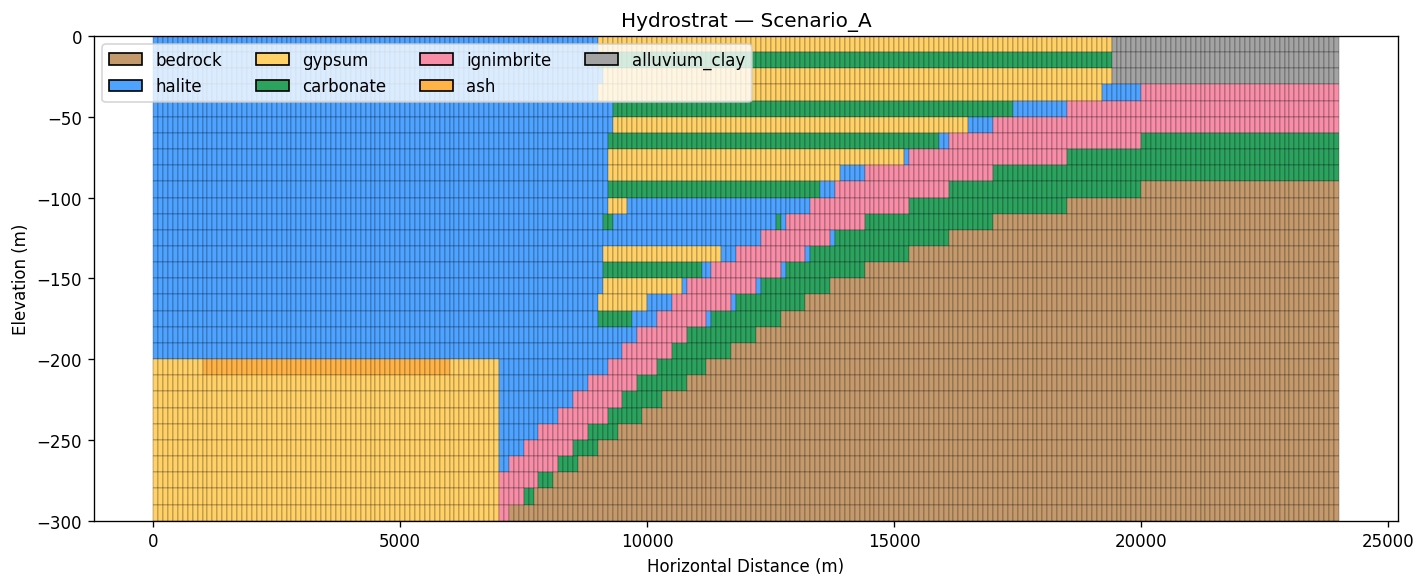

C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(


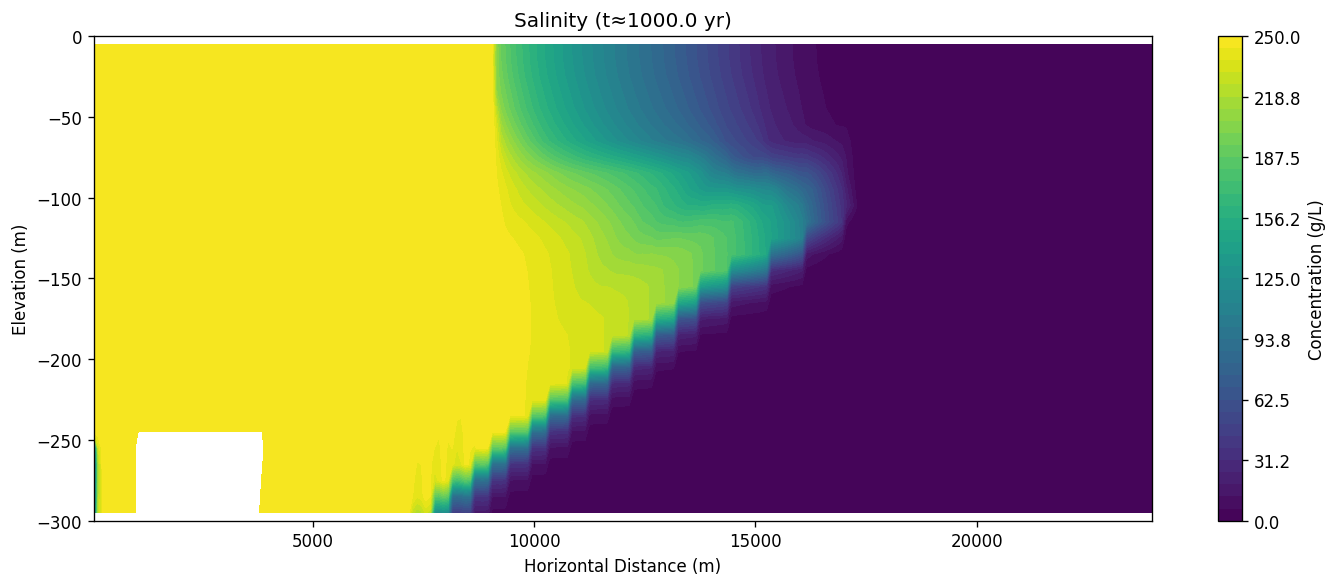

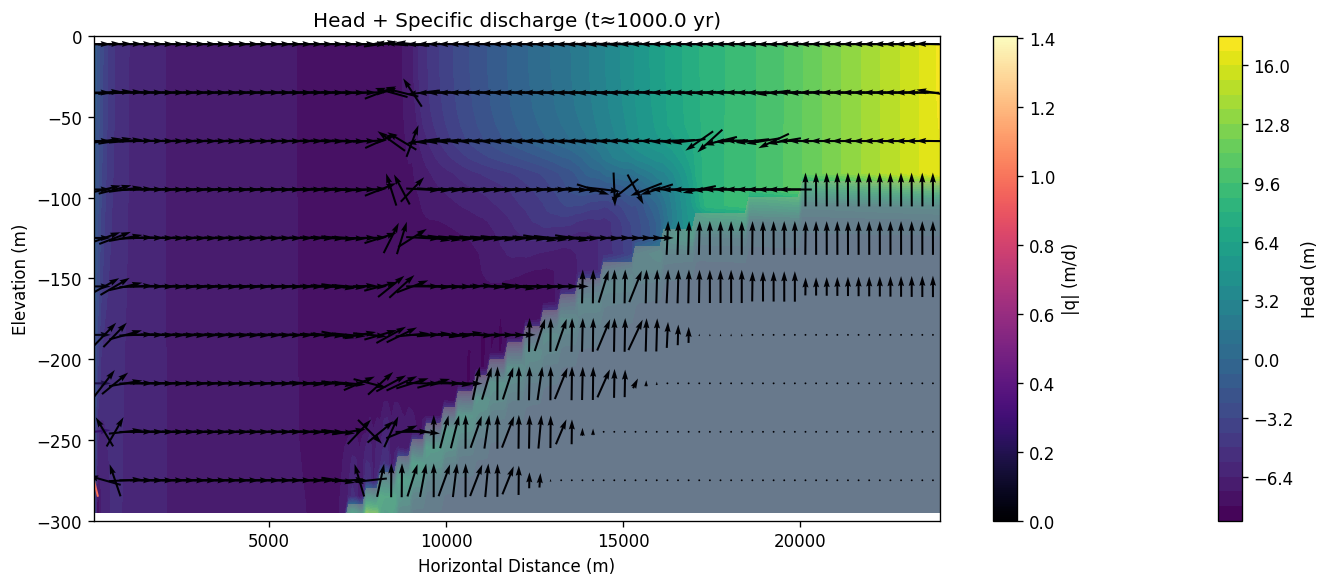

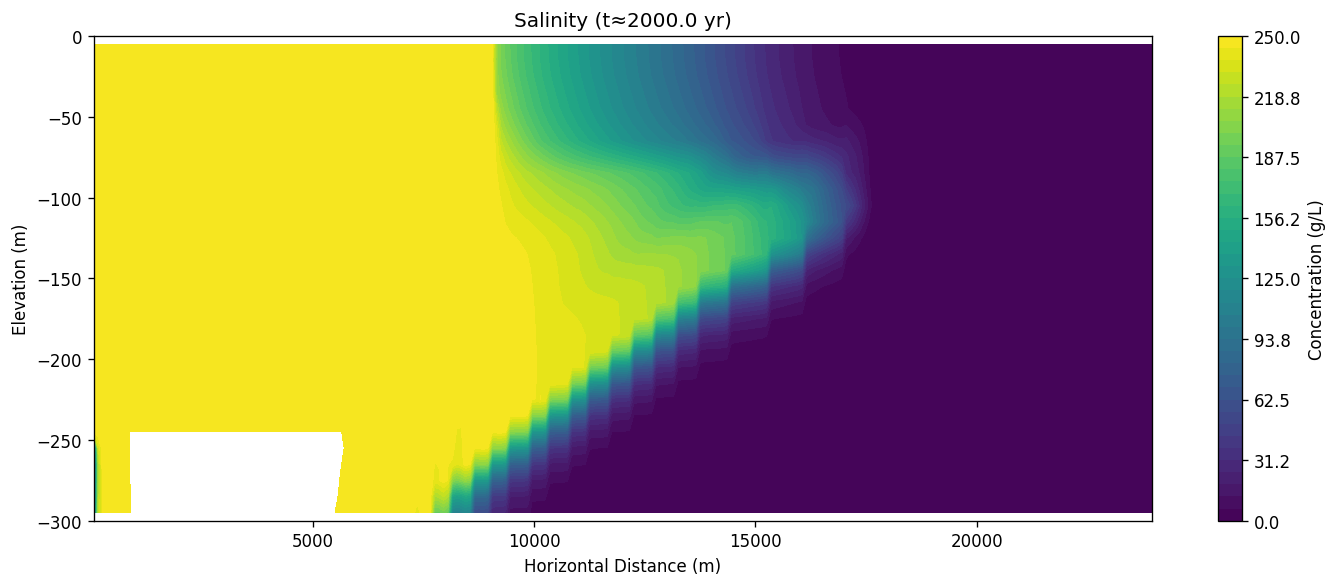

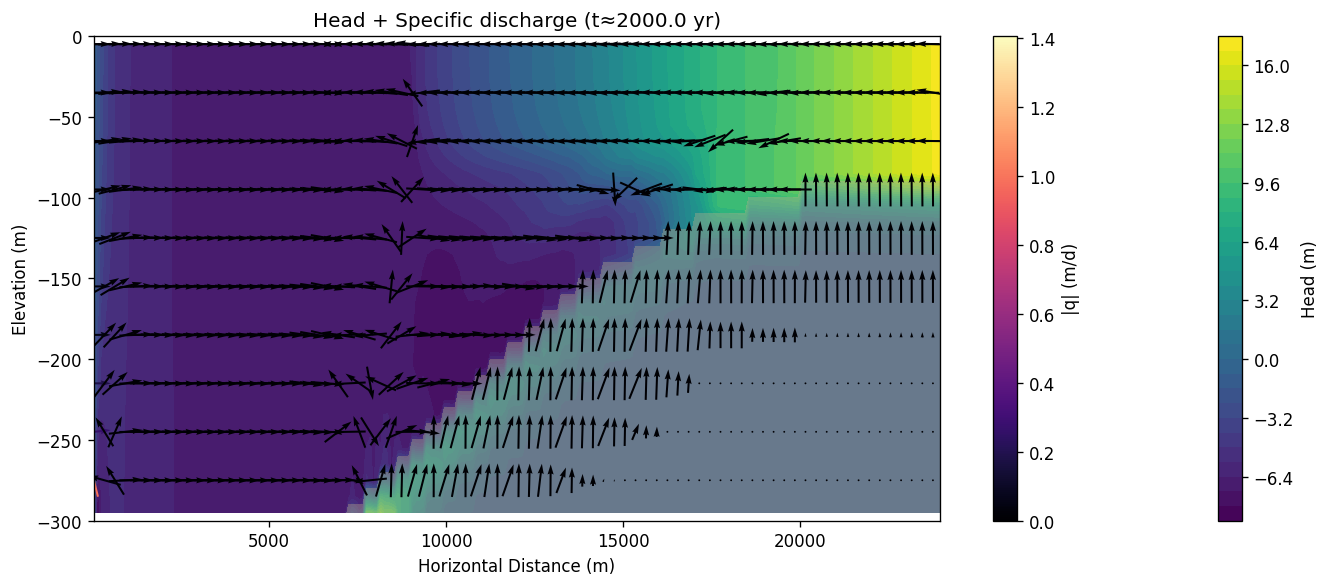

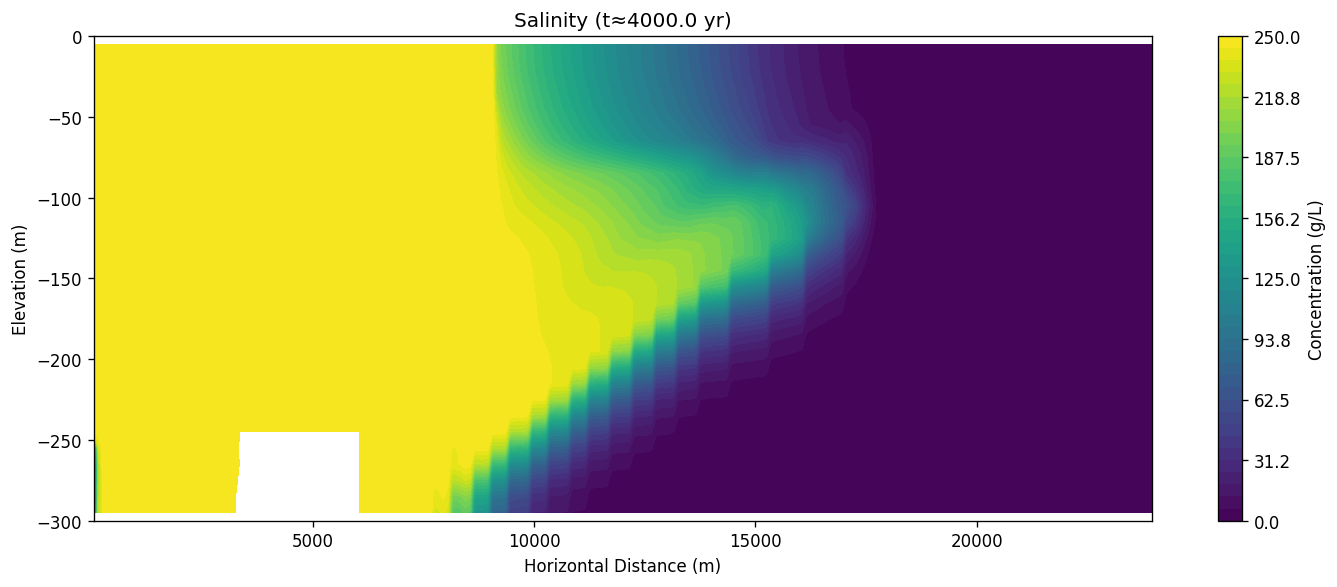

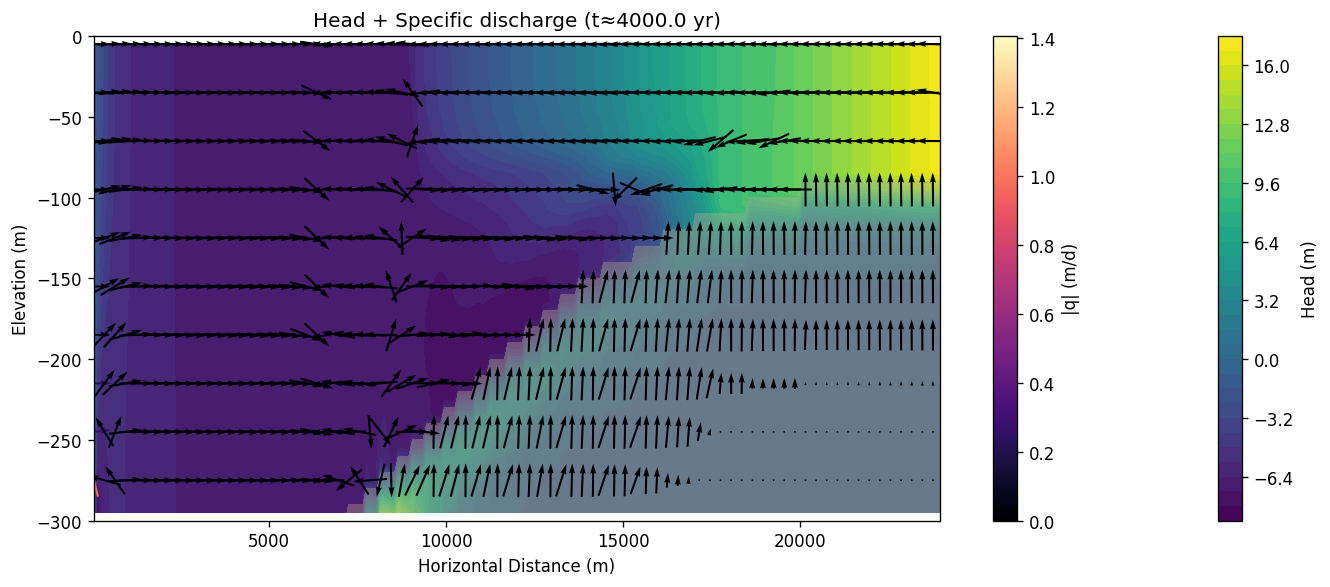

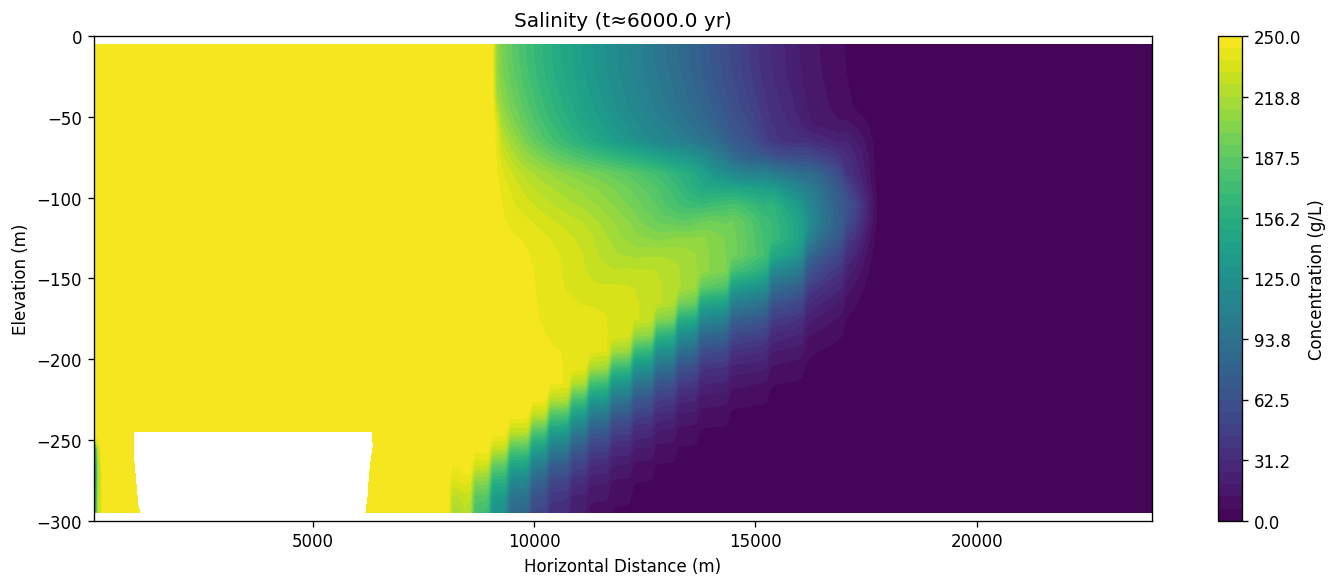

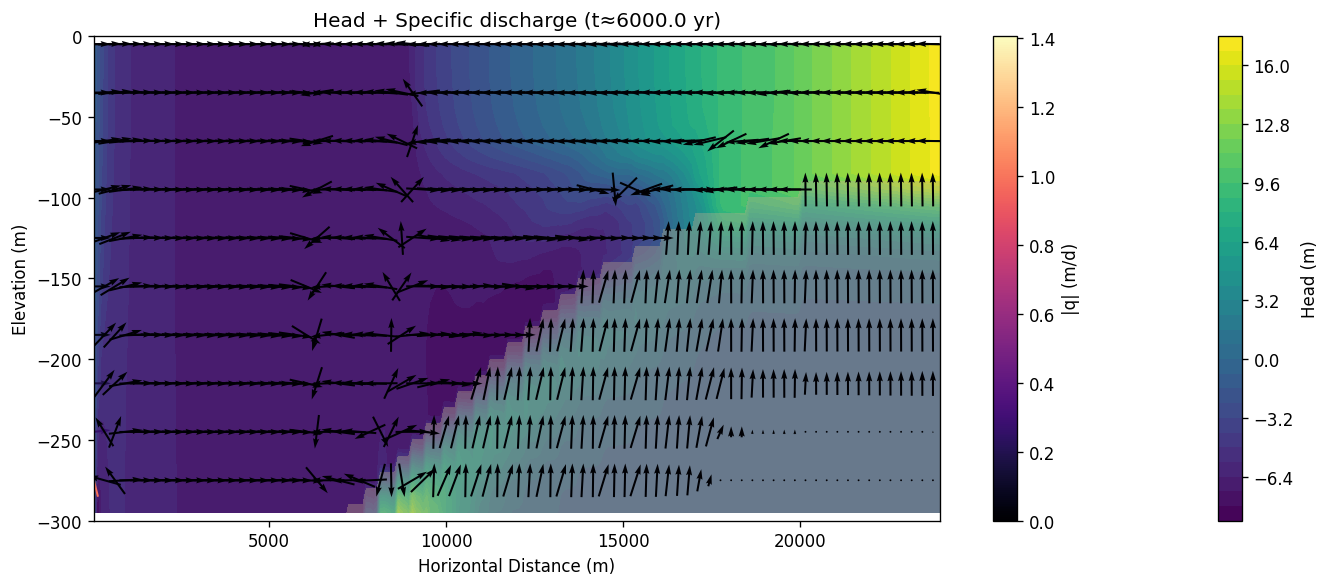

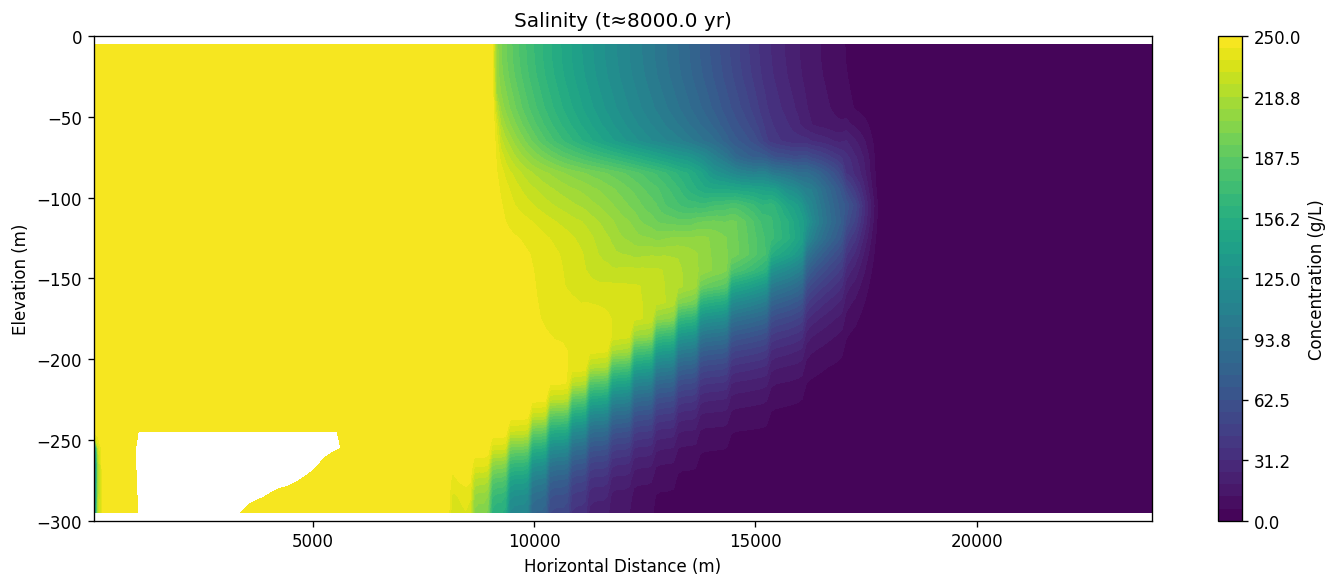

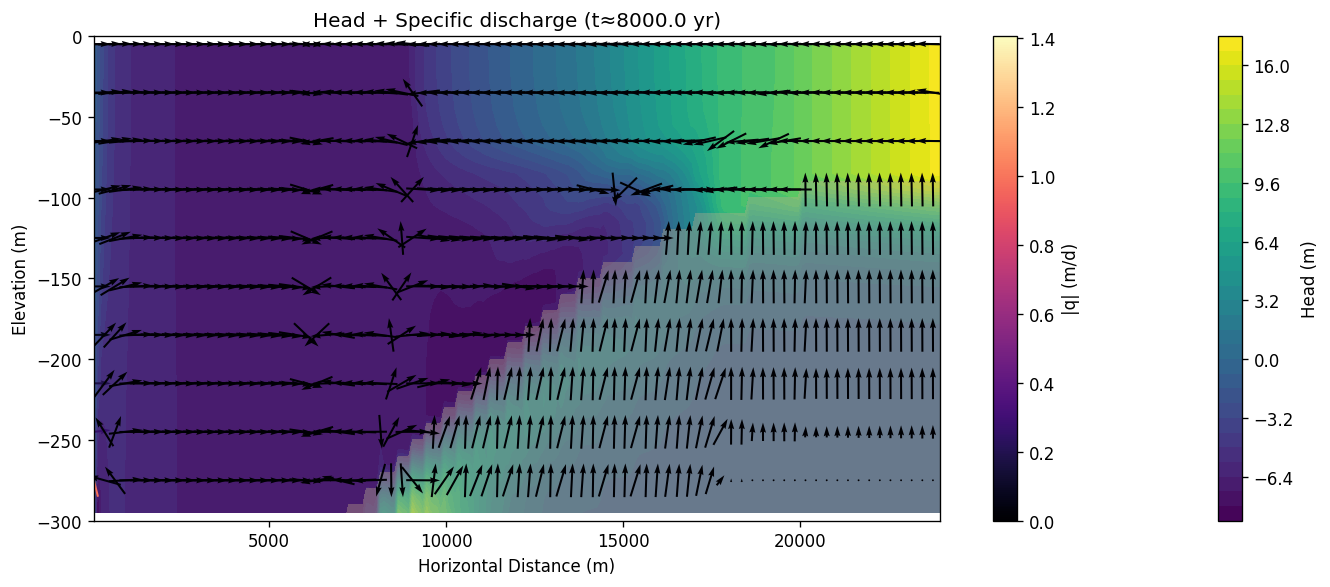

In [5]:
# ============================== Block 5 (run + plots; uses global time settings) ==============================
from shutil import rmtree
from pathlib import Path as _Path
import numpy as np
import flopy.utils as fu

# --- choose your run folder name (subfolder under CS_A1/) ---
run_name = "Scenario_A"   # <-- change only this if you want a different folder name

# --- snapshot years for plots/diagnostics ---
SNAPSHOT_YEARS = [1000, 2000, 4000, 6000, 8000]

# --- scenario + inflow (Scenario_A is the key you defined in Block 1) ---
scenario_key = "Scenario_A"
geo = scenarios[scenario_key]
inflow_val = float(parameters[scenario_key]["inflow"])

print(f"\n=== Running {run_name} (CHD @ x=0; shallow halite CNC 0–9 km; DRN 9.5–15 km; right fresh WEL) ===")

print("Workspace:", workspace)

# --- clean previous run directory ---
run_dir = workspace / run_name
rmtree(run_dir, ignore_errors=True)

# --- build + write + run (uses global nper/perlen/nstp/tsmult from Block 1) ---
sim = build_models(run_name, inflow=inflow_val, geo=geo)

write_models(sim, silent=True)
ok, _ = sim.run_simulation(silent=False)
if not ok:
    try:
        lst = (workspace / run_name / "mfsim.lst")
        tail = "\n".join(lst.read_text(errors="ignore").splitlines()[-200:])
        print("\n--- Tail of mfsim.lst ---\n" + tail)
    except Exception as e:
        print(f"(Could not read mfsim.lst: {e})")
    raise RuntimeError("MODFLOW 6 failed.")

# --- final-time diagnostics (water budget + heads) ---
bud_path = (workspace / run_name / "flow.bud").as_posix()
cbb = fu.CellBudgetFile(bud_path)
t_last = cbb.get_times()[-1]

# Full water budget
names = [n.decode().strip() if isinstance(n,(bytes,bytearray)) else str(n).strip()
         for n in cbb.get_unique_record_names()]
totals = {}
for nm in names:
    recs = cbb.get_data(text=nm, totim=t_last)
    if not recs: 
        continue
    a = recs[0]
    val = float(np.nansum(a["q"])) if getattr(a,"dtype",None) and a.dtype.names and "q" in a.dtype.names else float(np.nansum(a))
    totals[nm] = totals.get(nm, 0.0) + val

tin  = sum(v for v in totals.values() if v > 0)
tout = sum(v for v in totals.values() if v < 0)
print("\n[water budget @ final]")
for k in sorted(totals.keys()):
    print(f"  {k:<24} {totals[k]:12.4f}")
print(f"  {'TOTAL IN':<24} {tin:12.4f}")
print(f"  {'TOTAL OUT':<24} {tout:12.4f}")
print(f"  {'IMBALANCE (IN+OUT)':<24} {tin+tout:12.6f}")

# Head min/max
H_last = fu.HeadFile(str((workspace / run_name) / "flow.hds")).get_data(totim=t_last)[:,0,:]
print("\nHead min/max:", float(np.nanmin(H_last)), float(np.nanmax(H_last)))

# --- plots ---
try:
    plot_hydrostrat(sim, title=f"Hydrostrat — {run_name}")
except Exception as e:
    print(f"[plot] hydrostrat failed: {e}")

for yrs in SNAPSHOT_YEARS:
    try:
        plot_salinity_at(sim, yrs, title_prefix="Salinity")
    except Exception as e:
        print(f"[plot] salinity {yrs} yr failed: {e}")
    try:
        plot_quiver_at(sim, yrs, every=3, title_prefix="Head + Specific discharge")
    except Exception as e:
        print(f"[plot] quiver {yrs} yr failed: {e}")


In [8]:
import numpy as np

gwt = sim.get_model("trans")
C_ic = np.asarray(gwt.ic.strt.array, float)[:, 0, :]  # (nlay, ncol)

# Treat anything > 0 g/L as brine for mask
brine_mask_ic = C_ic > 0.0

n_brine = int(np.count_nonzero(brine_mask_ic))
k_idx, j_idx = np.where(brine_mask_ic)

print("[IC DEBUG] brine cells:", n_brine)
if n_brine > 0:
    print("  layer index range (k):", int(k_idx.min()), "to", int(k_idx.max()))
    print("  column index range (j):", int(j_idx.min()), "to", int(j_idx.max()))


[IC DEBUG] brine cells: 2242
  layer index range (k): 0 to 24
  column index range (j): 0 to 90


In [9]:
# ============================== Block 6 (diagnostics + Excel export) ==============================
from pathlib import Path as _Path
import numpy as np
import pandas as pd
import flopy.utils as fu

# ---------- basic helpers ----------
def _decode_name(n):
    if isinstance(n, (bytes, bytearray)):
        return n.decode("utf-8", "ignore").strip()
    return str(n).strip()

def _nearest_time(times, target):
    times = [float(t) for t in times]
    idx = int(np.argmin([abs(t - target) for t in times]))
    return float(times[idx])

def _nearest_head_time(sim, target_totim):
    """Nearest time in flow.hds to target_totim (days)."""
    gwf = sim.get_model("flow")
    p = _Path(gwf.model_ws) / "flow.hds"
    if not p.exists() or p.stat().st_size < 512:
        return None
    for cls, kw in [(fu.HeadFile, {"precision": "double"}),
                    (fu.HeadFile, {"precision": "single"})]:
        try:
            fh = cls(p.as_posix(), **kw)
            times = fh.get_times()
            if times:
                return _nearest_time(times, float(target_totim))
        except Exception:
            continue
    return None

# ---------- concentration helpers ----------
def _open_ucn_with_fallback(path):
    """Return (handler, times) or (None, None) for trans.ucn."""
    tries = [
        (fu.UcnFile, {"precision": "double"}),
        (fu.UcnFile, {"precision": "single"}),
        (fu.HeadFile, {"text": "CONCENTRATION", "precision": "double"}),
        (fu.HeadFile, {"text": "CONCENTRATION", "precision": "single"}),
    ]
    for cls, kw in tries:
        try:
            fh = cls(path.as_posix(), **kw)
            ts = fh.get_times()
            if ts:
                return fh, ts
        except Exception:
            continue
    print("[debug ucn] could not read times with any handler")
    return None, None

def _read_conc_at_nearest(sim, target_totim):
    """Return (totim_used, C[nlay,ncol]) or (None, None)."""
    gwt = sim.get_model("trans")
    if gwt is None:
        return None, None
    p = _Path(gwt.model_ws) / "trans.ucn"
    if not p.exists() or p.stat().st_size < 512:
        return None, None

    fh, times = _open_ucn_with_fallback(p)
    if fh is None:
        return None, None

    t_use = _nearest_time(times, float(target_totim))
    try:
        arr = fh.get_data(totim=t_use)  # (nlay, nrow, ncol)
        C = np.asarray(arr, float)[:, 0, :]
        return t_use, C
    except Exception:
        return None, None

# ---------- water & salt budgets ----------
def _water_budget(sim, totim):
    """Return dict {term: m3/d} from flow.bud at totim."""
    gwf = sim.get_model("flow")
    cbb_path = _Path(gwf.model_ws) / "flow.bud"
    if not cbb_path.exists():
        return {}

    cbb = fu.CellBudgetFile(cbb_path.as_posix(), precision="double")
    out = {}

    for raw in cbb.get_unique_record_names():
        name_decoded = _decode_name(raw)

        # Try both raw and decoded text keys
        recs = None
        try:
            recs = cbb.get_data(text=raw, totim=totim)
        except Exception:
            pass
        if not recs:
            try:
                recs = cbb.get_data(text=name_decoded, totim=totim)
            except Exception:
                recs = None
        if not recs:
            continue

        arr = recs[0]
        val = None

        if hasattr(arr, "dtype"):
            names = getattr(arr.dtype, "names", None)
            if names is not None and ("q" in names):
                val = float(np.nansum(arr["q"]))

        if val is None:
            val = float(np.nansum(arr))

        out[name_decoded] = out.get(name_decoded, 0.0) + val

    return out

def _salt_flow_budget(sim, totim):
    """Return dict {term: kg/d} from trans.cbc at totim."""
    gwt = sim.get_model("trans")
    if gwt is None:
        return {}
    cbb_path = _Path(gwt.model_ws) / "trans.cbc"
    if not cbb_path.exists():
        return {}

    cbb = fu.CellBudgetFile(cbb_path.as_posix(), precision="double")
    out = {}

    for raw in cbb.get_unique_record_names():
        name_decoded = _decode_name(raw)

        recs = None
        try:
            recs = cbb.get_data(text=raw, totim=totim)
        except Exception:
            pass
        if not recs:
            try:
                recs = cbb.get_data(text=name_decoded, totim=totim)
            except Exception:
                recs = None
        if not recs:
            continue

        arr = recs[0]
        val = None

        if hasattr(arr, "dtype"):
            names = getattr(arr.dtype, "names", None)
            if names is not None and ("q" in names):
                val = float(np.nansum(arr["q"]))

        if val is None:
            val = float(np.nansum(arr))

        out[name_decoded] = out.get(name_decoded, 0.0) + val

    return out

def _salt_budget(sim, totim):
    """
    Aquifer salt mass (kg) at totim, using porosity * volume * C.
    Assumes 1 g/L ≈ 1 kg/m3.
    """
    gwf = sim.get_model("flow")
    gwt = sim.get_model("trans")
    if gwf is None or gwt is None:
        return {}

    dis = gwf.get_package("dis")
    delr = np.asarray(dis.delr.array, float)          # (ncol,)
    delc_arr = np.asarray(dis.delc.array)
    if delc_arr.ndim == 0:
        delc = float(delc_arr)
    else:
        delc = float(delc_arr[0])
    topA = float(dis.top.array[0, 0])
    botmA = float(dis.botm.array[-1, 0, 0])
    nlay = int(dis.nlay.data)
    dz = (topA - botmA) / nlay

    t_used, C = _read_conc_at_nearest(sim, totim)
    if C is None:
        return {}

    vol = np.outer(np.ones(nlay) * dz, delr) * delc   # m3
    theta = float(globals().get("porosity_const", 0.30))
    salt_mass_kg = float(np.nansum(C * theta * vol))
    return {"totim_d": t_used, "aquifer_salt_mass_kg": salt_mass_kg}

# ---------- interface & column stats ----------
def _interface_by_column(sim, totim, cutoff_gL=100.0):
    """Interface depth (first cell >= cutoff_gL) for each column."""
    gwt = sim.get_model("trans")
    if gwt is None:
        return pd.DataFrame()

    dis = gwt.get_package("dis")
    nlay = int(dis.nlay.data)
    ncol = int(dis.ncol.data)
    topA = float(dis.top.array[0, 0])
    botmA = float(dis.botm.array[-1, 0, 0])

    t_used, C = _read_conc_at_nearest(sim, totim)
    if C is None:
        return pd.DataFrame()

    depths = np.full(ncol, np.nan)
    for j in range(ncol):
        hits = np.where(C[:, j] >= float(cutoff_gL))[0]
        if hits.size > 0:
            k = int(hits[0])
            zc = topA - (k + 0.5) * (topA - botmA) / nlay   # elevation
            depths[j] = -zc                                  # +down

    return pd.DataFrame({"col": np.arange(ncol, dtype=int),
                         "depth_m_pos_down": depths})

def _conc_column_means(sim, totim):
    """Mean concentration per column."""
    t_used, C = _read_conc_at_nearest(sim, totim)
    if C is None:
        return pd.DataFrame()
    means = np.nanmean(C, axis=0)
    return pd.DataFrame({"col": np.arange(C.shape[1], dtype=int),
                         "C_mean_gL": means})

# ---------- console diagnostics ----------
def run_diagnostics(sim, years_list=(100, 500, 1000)):
    for yrs in years_list:
        target = float(yrs) * 365.0
        t_use = _nearest_head_time(sim, target)
        if t_use is None:
            print(f"\n[diagnostics] No data near {yrs} yr.")
            continue

        print("\n" + "="*70)
        print(f"DIAGNOSTICS @ t ≈ {t_use/365.0:.2f} yr")
        print("="*70)

        bud = _water_budget(sim, t_use)
        if bud:
            print("\n=== WATER BUDGET (m³/d) ===")
            for k in sorted(bud.keys()):
                print(f"  {k:<30} {bud[k]:12.4f}")
            tin  = sum(v for v in bud.values() if v > 0)
            tout = sum(v for v in bud.values() if v < 0)
            print(f"  {'TOTAL IN':<30} {tin:12.4f}")
            print(f"  {'TOTAL OUT':<30} {tout:12.4f}")
            print(f"  {'IMBALANCE (IN+OUT)':<30} {tin+tout:12.6f}")

        sb = _salt_budget(sim, t_use)
        if sb:
            print("\n=== SALT MASS ===")
            print(f"  Aquifer salt mass (kg): {sb['aquifer_salt_mass_kg']:.4e}")

# ---------- Excel export ----------
def export_snapshots_to_excel(sim, years_list, xlsx_path="budgets_and_salinity.xlsx", cutoff_gL=100.0):
    gwf = sim.get_model("flow")
    out_tables = {}

    # Water budget (long)
    wb_rows = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, yrs*365.0)
        if t_use is None:
            continue
        bud = _water_budget(sim, t_use)
        if not bud:
            continue
        tin  = sum(v for v in bud.values() if v > 0)
        tout = sum(v for v in bud.values() if v < 0)
        for k, v in bud.items():
            wb_rows.append({"year": yrs, "term": k, "value_m3_d": v})
        wb_rows.append({"year": yrs, "term": "TOTAL IN",  "value_m3_d": tin})
        wb_rows.append({"year": yrs, "term": "TOTAL OUT", "value_m3_d": tout})
        wb_rows.append({"year": yrs, "term": "IMBALANCE (IN+OUT)", "value_m3_d": tin+tout})
    if wb_rows:
        out_tables["water_budget_long"] = pd.DataFrame(wb_rows)

    # Interface by column
    iface_rows = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, yrs*365.0)
        if t_use is None:
            continue
        df = _interface_by_column(sim, t_use, cutoff_gL=cutoff_gL)
        if not df.empty:
            df["year"] = yrs
            iface_rows.append(df)
    if iface_rows:
        out_tables["interface_by_column"] = pd.concat(iface_rows, ignore_index=True)

    # Column mean concentration
    cm_rows = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, yrs*365.0)
        if t_use is None:
            continue
        df = _conc_column_means(sim, t_use)
        if not df.empty:
            df["year"] = yrs
            cm_rows.append(df)
    if cm_rows:
        out_tables["conc_column_means"] = pd.concat(cm_rows, ignore_index=True)

    # Salt mass (aquifer)
    sm_rows = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, yrs*365.0)
        if t_use is None:
            continue
        sb = _salt_budget(sim, t_use)
        if sb:
            sm_rows.append({"year": yrs,
                            "aquifer_salt_mass_kg": sb["aquifer_salt_mass_kg"]})
    if sm_rows:
        out_tables["salt_mass"] = pd.DataFrame(sm_rows)

    # Salt flow budget (long)
    sfb_rows = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, yrs*365.0)
        if t_use is None:
            continue
        sfb = _salt_flow_budget(sim, t_use)
        if not sfb:
            continue
        tin  = sum(v for v in sfb.values() if v > 0)
        tout = sum(v for v in sfb.values() if v < 0)
        for k, v in sfb.items():
            sfb_rows.append({"year": yrs, "term": k, "value_kg_d": v})
        sfb_rows.append({"year": yrs, "term": "TOTAL IN",  "value_kg_d": tin})
        sfb_rows.append({"year": yrs, "term": "TOTAL OUT", "value_kg_d": tout})
        sfb_rows.append({"year": yrs, "term": "IMBALANCE (IN+OUT)", "value_kg_d": tin+tout})
    if sfb_rows:
        out_tables["salt_flow_budget_long"] = pd.DataFrame(sfb_rows)

    # Write Excel
    outp = _Path(gwf.model_ws).parent / xlsx_path
    try:
        with pd.ExcelWriter(outp.as_posix(), engine="openpyxl", mode="w") as xlw:
            for sheet, df in out_tables.items():
                df.to_excel(xlw, sheet_name=sheet, index=False)
        print(f"[export] Wrote tables to: {outp}")
    except Exception as e:
        print(f"[export] Excel export failed: {e}")

# ---------- run export + diagnostics ----------
try:
    _yrs = list(SNAPSHOT_YEARS) if "SNAPSHOT_YEARS" in globals() else [100, 500, 1000]
    export_snapshots_to_excel(sim, _yrs, xlsx_path="budgets_and_salinity.xlsx", cutoff_gL=100.0)
except Exception as e:
    print(f"[export] Excel export failed: {e}")

try:
    run_diagnostics(sim, years_list=(list(SNAPSHOT_YEARS) if "SNAPSHOT_YEARS" in globals() else [100, 500, 1000]))
except Exception as e:
    print(f"[diagnostics] failed: {e}")


C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Py

[export] Wrote tables to: C:\Jupyterbook\CS_A1\budgets_and_salinity.xlsx

DIAGNOSTICS @ t ≈ 1000.00 yr

=== WATER BUDGET (m³/d) ===
  CHD                                  0.7636
  DATA-SPDIS                           0.0000
  DRN                                 -0.5607
  FLOW-JA-FACE                        -0.0002
  STO-SS                              -0.7031
  WEL                                  0.5000
  TOTAL IN                             1.2636
  TOTAL OUT                           -1.2640
  IMBALANCE (IN+OUT)                -0.000400

=== SALT MASS ===
  Aquifer salt mass (kg): 2.6745e+08

DIAGNOSTICS @ t ≈ 2000.00 yr

=== WATER BUDGET (m³/d) ===
  CHD                                  0.7197
  DATA-SPDIS                           0.0000
  DRN                                 -0.5164
  FLOW-JA-FACE                         0.0006
  STO-SS                              -0.7027
  WEL                                  0.5000
  TOTAL IN                             1.2202
  TOTAL OUT      

In [10]:
# 1) Head profile along top active layer at final time
import flopy.utils as fu
import numpy as np
from pathlib import Path

gwf = sim.get_model("flow")
hds = fu.HeadFile((Path(gwf.model_ws) / "flow.hds").as_posix())
t_last = hds.get_times()[-1]
H = hds.get_data(totim=t_last)[0, 0, :]  # (ncol,)

print("Top layer heads at final time:")
print("min:", H.min(), "max:", H.max(), "range:", H.max() - H.min())


Top layer heads at final time:
min: -5.141303961791822 max: 14659.955276266963 range: 14665.096580228754
